# Análisis estadístico descriptivo: Inventario de productos

- **Equipo 2:** Héctor Oropeza, Diego Lara, Jorge Alvarez
- **Materia:** Big Data para Negocios
- **Profesor:** Abel Soto
- **Conjunto de datos:** Online Retail II (UCI), publicado en Kaggle como Supermarket Dataset con el archivo `supermarket_data.csv` (https://www.kaggle.com/datasets/saurabhbadole/supermarket-data)

El conjunto de datos contiene las líneas de venta de una tienda en línea de artículos de regalo con sede en Reino Unido, entre el 1 de diciembre de 2010 y el 9 de diciembre de 2011. Cada fila es un producto dentro de una factura.

Aunque en Kaggle se llama Supermarket Dataset, su contenido es la hoja "Year 2010-2011" del conjunto Online Retail II de UCI (Chen, 2019), con las mismas columnas y las mismas 541,910 filas. Son ventas de una tienda de artículos de regalo, no de un supermercado.

In [1]:
# Captura 1: Librerías, rutas y obtención de los datos
import hashlib
import io
import sys
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import matplotlib

EN_COLAB = "google.colab" in sys.modules

# Rutas del proyecto: funciona desde la carpeta notebooks, desde la raíz del repositorio o en Colab
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw" / "online_retail.csv"
PROCESSED = ROOT / "data" / "processed" / "online_retail_clean.csv"
TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"
for carpeta in [RAW.parent, PROCESSED.parent, TABLES, FIGURES]:
    carpeta.mkdir(parents=True, exist_ok=True)

# Si el archivo original no está (por ejemplo, en Colab), se descarga de Kaggle.
# Si Kaggle no responde, se usa la copia guardada en el repositorio del equipo.
URL_KAGGLE = "https://www.kaggle.com/api/v1/datasets/download/saurabhbadole/supermarket-data"
URL_REPOSITORIO = ("https://raw.githubusercontent.com/GoldenDiegos/big-data-inventario-productos-online-retail/"
                   "main/data/raw/online_retail.csv")
if not RAW.exists():
    try:
        print("Descargando el conjunto de datos desde Kaggle...")
        with urllib.request.urlopen(URL_KAGGLE, timeout=60) as respuesta:
            with zipfile.ZipFile(io.BytesIO(respuesta.read())) as z:
                RAW.write_bytes(z.read("supermarket_data.csv"))
    except Exception as error:
        print("Kaggle no respondió (", error, "). Descargando la copia del repositorio...")
        with urllib.request.urlopen(URL_REPOSITORIO, timeout=120) as respuesta:
            RAW.write_bytes(respuesta.read())

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Entorno:", "Google Colab" if EN_COLAB else "local")
print("Python", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)
print("Archivo de datos:", RAW.relative_to(ROOT).as_posix())

Entorno: local
Python 3.14.3 | pandas 3.0.6 | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2
Archivo de datos: data/raw/online_retail.csv


## 1. Carga y verificación de los datos

Antes de cargar el archivo se compara su huella SHA-256 con la del archivo descargado de Kaggle. Si coinciden, el archivo no fue modificado.

In [2]:
# Captura 2: Verificación del archivo original y carga de datos
SHA256_ORIGINAL = "cb304b33513787ba84fc0e7d38b21f49279f6817e48f99d6d3cc3a849cc436ca"
sha = hashlib.sha256(RAW.read_bytes()).hexdigest()
assert sha == SHA256_ORIGINAL, "El archivo original fue modificado"
print("Huella SHA-256 verificada:", sha)

raw = pd.read_csv(RAW, dtype={"Invoice": str, "StockCode": str, "Customer ID": "Int64"})
print(f"Filas: {raw.shape[0]:,}  Columnas: {raw.shape[1]}")
raw.head(10)

Huella SHA-256 verificada: cb304b33513787ba84fc0e7d38b21f49279f6817e48f99d6d3cc3a849cc436ca


Filas: 541,910  Columnas: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 08:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 08:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 08:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 08:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 08:26,3.39,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01/12/10 08:26,7.65,17850,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01/12/10 08:26,4.25,17850,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01/12/10 08:28,1.85,17850,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01/12/10 08:28,1.85,17850,United Kingdom
9,536368,22960,JAM MAKING SET WITH JARS,6,01/12/10 08:34,4.25,13047,United Kingdom


### Diccionario de datos

| Columna | Descripción |
|---|---|
| Invoice | Número de factura. Si empieza con C es una cancelación y si empieza con A es un ajuste contable. |
| StockCode | Código del producto en inventario. |
| Description | Nombre del producto. |
| Quantity | Unidades vendidas en la línea. Los valores negativos son devoluciones o cancelaciones. |
| InvoiceDate | Fecha y hora de la factura, en formato día/mes/año. |
| Price | Precio unitario en libras esterlinas (£). |
| Customer ID | Identificador del cliente. |
| Country | País del cliente. |

In [3]:
# Captura 3: Estructura de los datos originales
estructura = pd.DataFrame({
    "Tipo": raw.dtypes.astype(str),
    "Valores nulos": raw.isna().sum(),
    "% nulos": (raw.isna().mean() * 100).round(2),
    "Valores únicos": raw.nunique(),
})
estructura

,Tipo,Valores nulos,% nulos,Valores únicos
Invoice,str,0,0.00,25900
StockCode,str,0,0.00,4070
Description,str,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,str,0,0.00,23260
Price,float64,0,0.00,1630
Customer ID,Int64,135080,24.93,4372
Country,str,0,0.00,38


### Problemas detectados en los datos originales

Se revisó cada columna para encontrar registros que no corresponden a ventas reales de productos o que tienen errores de formato.

In [4]:
# Captura 4: Diagnóstico de calidad de los datos originales
SERVICIOS = ["POST", "DOT", "M", "C2", "D", "S", "BANK CHARGES", "AMAZONFEE", "CRUK", "B", "PADS",
             "23444", "23702", "22016"]  # envío al día siguiente, imagen digital, vale de regalo de £100
codigo = raw["StockCode"].str.strip().str.upper()
desc = raw["Description"]

diagnostico = pd.DataFrame([
    ("Filas duplicadas exactas", raw.duplicated().sum()),
    ("Facturas canceladas (prefijo C)", raw["Invoice"].str.startswith("C").sum()),
    ("Ajustes contables (prefijo A)", raw["Invoice"].str.startswith("A").sum()),
    ("Cantidad menor o igual a 0", (raw["Quantity"] <= 0).sum()),
    ("Precio menor o igual a 0", (raw["Price"] <= 0).sum()),
    ("Códigos de servicio o vales de regalo", (codigo.isin(SERVICIOS) | codigo.str.startswith("GIFT_")).sum()),
    ("Descripción vacía", desc.isna().sum()),
    ("Descripción con espacios sobrantes", (desc.notna() & (desc != desc.str.strip().str.replace(r"\s+", " ", regex=True))).sum()),
    ("Código de producto en minúsculas", raw["StockCode"].str.contains("[a-z]").sum()),
    ("Customer ID vacío", raw["Customer ID"].isna().sum()),
], columns=["Problema", "Registros"])
diagnostico.style.format({"Registros": "{:,}"}).hide(axis="index")

Problema,Registros
Filas duplicadas exactas,"5,268"
Facturas canceladas (prefijo C),"9,288"
Ajustes contables (prefijo A),3
Cantidad menor o igual a 0,"10,624"
Precio menor o igual a 0,"2,517"
Códigos de servicio o vales de regalo,"3,037"
Descripción vacía,"1,454"
Descripción con espacios sobrantes,"128,367"
Código de producto en minúsculas,"1,977"
Customer ID vacío,"135,080"


## 2. Limpieza de datos

Reglas aplicadas, en este orden:

1. **Normalización de texto:** códigos de producto en mayúsculas, descripciones sin espacios sobrantes y un solo nombre por código. Algunos códigos tenían variantes de nombre (por ejemplo, "JUMBO BAG VINTAGE DOILY" y "JUMBO BAG DOILEY PATTERNS"); a cada código se le asigna su descripción más frecuente. No elimina filas, pero evita que un mismo producto se cuente dos veces.
2. **Duplicados exactos:** filas idénticas en todas las columnas.
3. **Ajustes contables (A):** son movimientos de deuda incobrable, no ventas.
4. **Compras revertidas:** compras que después fueron canceladas por el mismo cliente, con el mismo producto, la misma cantidad y el mismo precio. Si solo se quitara la cancelación, la compra original seguiría contando como venta aunque nunca se concretó.
5. **Facturas canceladas (C):** las cancelaciones en sí.
6. **Códigos de servicio:** envíos (POST, DOT, C2, 23444), cargos manuales (M), descuentos (D), muestras (S), comisiones (BANK CHARGES, AMAZONFEE, CRUK), ajustes (B), rellenos para cojines registrados a £0.001 (PADS), imagen digital (23702) y vales de regalo (GIFT_ y 22016). No son productos del inventario.
7. **Cantidad menor o igual a 0:** devoluciones y ajustes de inventario sin factura de cancelación.
8. **Precio menor o igual a 0:** registros internos sin valor de venta (por ejemplo, "damaged" o "check").
9. **Facturas anuladas por nota de crédito manual:** algunas cancelaciones se registraron con el código M por el importe total de una factura. Cuando el importe coincide al centavo con una factura previa del mismo cliente, esa factura se elimina.
10. **Descripción vacía.**

Los valores vacíos de Customer ID **no se eliminan**: corresponden a ventas reales a clientes no registrados y el análisis no depende de esa columna.

In [5]:
# Captura 5: Normalización de texto y función de bitácora
df = raw.rename(columns={"Customer ID": "CustomerID"}).copy()
df["StockCode"] = df["StockCode"].str.strip().str.upper()
df["Description"] = df["Description"].str.strip().str.replace(r"\s+", " ", regex=True)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%d/%m/%y %H:%M")

# Un mismo código puede tener variantes de nombre ("DOILY" y "DOILEY"). A cada código se le asigna
# la descripción más frecuente entre sus ventas válidas (cantidad y precio mayores a 0).
ventas_validas = df[df["Description"].notna() & (df["Quantity"] > 0) & (df["Price"] > 0)
                    & ~df["Invoice"].str.startswith(("C", "A"))]
canonica = (ventas_validas.groupby(["StockCode", "Description"]).size().reset_index(name="n")
              .sort_values(["StockCode", "n", "Description"], ascending=[True, False, True])
              .drop_duplicates("StockCode").set_index("StockCode")["Description"])
variantes = ventas_validas.groupby("StockCode")["Description"].nunique()
tiene_canonica = df["Description"].notna() & df["StockCode"].isin(canonica.index)
df.loc[tiene_canonica, "Description"] = df.loc[tiene_canonica, "StockCode"].map(canonica)
print(f"Códigos con variantes de nombre unificados: {(variantes > 1).sum()}")

bitacora = []

def registrar(regla, antes, despues):
    bitacora.append({
        "Paso": len(bitacora) + 1,
        "Regla": regla,
        "Filas antes": len(antes),
        "Filas después": len(despues),
        "Filas eliminadas": len(antes) - len(despues),
    })
    return despues

df = registrar("Normalización de texto y fechas", raw, df)
print("Rango de fechas:", df["InvoiceDate"].min(), "a", df["InvoiceDate"].max())

Códigos con variantes de nombre unificados: 207
Rango de fechas: 2010-12-01 08:26:00 a 2011-12-09 12:50:00


In [6]:
# Captura 6: Duplicados, ajustes contables y detección de compras revertidas
df = registrar("Duplicados exactos", df, df.drop_duplicates())
df = registrar("Ajustes contables (prefijo A)", df, df[~df["Invoice"].str.startswith("A")])

# Cada cancelación se empareja con la compra previa más reciente del mismo cliente,
# mismo código de producto, misma cantidad y mismo precio. Cada compra se usa una sola vez.
es_cancelacion = df["Invoice"].str.startswith("C")
cancelaciones = df[es_cancelacion & df["CustomerID"].notna()]
compras = df[~es_cancelacion & (df["Quantity"] > 0) & df["CustomerID"].notna()]

candidatos = compras.reset_index().merge(
    cancelaciones.reset_index()
        .assign(Quantity=lambda x: -x["Quantity"])
        [["index", "CustomerID", "StockCode", "Quantity", "Price", "InvoiceDate"]]
        .rename(columns={"index": "idx_cancelacion", "InvoiceDate": "FechaCancelacion"}),
    on=["CustomerID", "StockCode", "Quantity", "Price"],
)
candidatos = candidatos[candidatos["InvoiceDate"] <= candidatos["FechaCancelacion"]]
candidatos = candidatos.sort_values(["FechaCancelacion", "idx_cancelacion", "InvoiceDate", "index"],
                                    ascending=[True, True, False, False])

revertidas = []
usadas = set()
for _, grupo in candidatos.groupby("idx_cancelacion", sort=False):
    for idx in grupo["index"]:
        if idx not in usadas:
            usadas.add(idx)
            revertidas.append(idx)
            break

print(f"Compras revertidas encontradas: {len(revertidas):,}")
print(f"Unidades que no se concretaron: {df.loc[revertidas, 'Quantity'].sum():,}")
print("\nCompras revertidas con mayor cantidad:")
df.loc[revertidas].nlargest(5, "Quantity")[["Invoice", "StockCode", "Description", "Quantity", "Price", "CustomerID", "InvoiceDate"]]

Compras revertidas encontradas: 2,769
Unidades que no se concretaron: 223,470

Compras revertidas con mayor cantidad:


,Invoice,StockCode,Description,Quantity,Price,CustomerID,InvoiceDate
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,2011-12-09 09:15:00
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346,2011-01-18 10:01:00
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749,2011-01-11 12:55:00
52710,540815,21175,GIN + TONIC DIET METAL SIGN,2000,1.85,15749,2011-01-11 12:55:00
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,15749,2011-01-11 12:55:00


In [7]:
# Captura 7: Resto de reglas de limpieza y bitácora
df = registrar("Compras revertidas por una cancelación", df, df.drop(index=revertidas))

# Las notas de crédito manuales (código M) se guardan antes de quitar las cancelaciones
creditos = df[df["Invoice"].str.startswith("C") & (df["StockCode"] == "M") & df["CustomerID"].notna()].copy()
creditos["Importe"] = (-creditos["Quantity"] * creditos["Price"]).round(2)

df = registrar("Facturas canceladas (prefijo C)", df, df[~df["Invoice"].str.startswith("C")])
es_servicio = df["StockCode"].isin(SERVICIOS) | df["StockCode"].str.startswith("GIFT_")
df = registrar("Códigos de servicio y vales de regalo", df, df[~es_servicio])
df = registrar("Cantidad menor o igual a 0", df, df[df["Quantity"] > 0])
df = registrar("Precio menor o igual a 0", df, df[df["Price"] > 0])

# Una nota de crédito manual cuyo importe es igual, al centavo, al total de una factura previa
# del mismo cliente anula esa factura completa
facturas = (df.assign(Importe=df["Quantity"] * df["Price"])
              .groupby(["Invoice", "CustomerID"], as_index=False)
              .agg(Importe=("Importe", "sum"), Fecha=("InvoiceDate", "min")))
facturas["Importe"] = facturas["Importe"].round(2)
acreditadas = []
for _, c in creditos.sort_values("InvoiceDate").iterrows():
    opciones = facturas[(facturas["CustomerID"] == c["CustomerID"]) & (facturas["Importe"] == c["Importe"])
                        & (facturas["Fecha"] <= c["InvoiceDate"]) & ~facturas["Invoice"].isin(acreditadas)]
    if len(opciones):
        acreditadas.append(opciones.sort_values("Fecha").iloc[-1]["Invoice"])
print(f"Facturas anuladas por nota de crédito manual: {len(acreditadas)}")
df = registrar("Facturas anuladas por nota de crédito manual", df, df[~df["Invoice"].isin(acreditadas)])
df = registrar("Descripción vacía", df, df[df["Description"].notna()])

bitacora_df = pd.DataFrame(bitacora)
total = pd.DataFrame([{
    "Paso": "", "Regla": "Total",
    "Filas antes": len(raw), "Filas después": len(df),
    "Filas eliminadas": len(raw) - len(df),
}])
bitacora_df = pd.concat([bitacora_df, total], ignore_index=True)
bitacora_df.style.format({c: "{:,}" for c in ["Filas antes", "Filas después", "Filas eliminadas"]}).hide(axis="index")

Facturas anuladas por nota de crédito manual: 20


Paso,Regla,Filas antes,Filas después,Filas eliminadas
1,Normalización de texto y fechas,"541,910","541,910",0
2,Duplicados exactos,"541,910","536,640","5,270"
3,Ajustes contables (prefijo A),"536,640","536,637",3
4,Compras revertidas por una cancelación,"536,637","533,868","2,769"
5,Facturas canceladas (prefijo C),"533,868","524,617","9,251"
6,Códigos de servicio y vales de regalo,"524,617","522,218","2,399"
7,Cantidad menor o igual a 0,"522,218","520,882","1,336"
8,Precio menor o igual a 0,"520,882","519,728","1,154"
9,Facturas anuladas por nota de crédito manual,"519,728","519,231",497
10,Descripción vacía,"519,231","519,231",0


### Casos que se conservaron y su justificación

- **Cancelaciones parciales:** cuando un cliente canceló solo una parte de lo comprado (por ejemplo, el cliente 12901 compró 1,200 piezas del producto 84077 y después canceló 960), la cantidad no coincide con ninguna compra y la compra se conserva completa. No es posible saber con certeza a qué línea corresponde la parte cancelada.
- **Cancelaciones con precio corregido:** en 6 casos el cliente canceló el mismo producto y la misma cantidad el mismo día, pero a un precio distinto (por ejemplo, un gabinete comprado a £295.00 y cancelado a £265.50). Como el precio no coincide, la compra se conserva. Suman alrededor de £692, menos del 0.01 % de las ventas.
- **Notas de crédito manuales:** la regla 9 depende de que el importe coincida al centavo con una factura del mismo cliente. En las 20 facturas anuladas el crédito es del mismo cliente, es posterior a la factura y cubre su importe completo.
- **Líneas repetidas con nombre distinto:** 2 líneas aparecían dos veces en la misma factura, con el mismo producto, cantidad, precio y hora, pero con el nombre escrito de otra forma. Al unificar los nombres se tratan como duplicados y se elimina una de cada par.
- **Cancelaciones sin compra en el periodo:** muchas cancelaciones de diciembre de 2010 no tienen una compra correspondiente en los datos, probablemente porque la compra se hizo antes del 1 de diciembre de 2010. No hay compra que eliminar.
- **Valores extremos:** las cantidades más altas que permanecen son pedidos de mayoreo reales (por ejemplo, 1,412 piezas a £5.06) y los precios más altos son artículos caros vendidos por unidad, como gabinetes de £295.00. El precio máximo, £649.50, es un lote de 60 canastas de picnic vendido como una sola unidad (su descripción original era "PICNIC BASKET WICKER 60 PIECES"); al unificar los nombres del código 22502 aparece como "PICNIC BASKET WICKER SMALL". No se eliminan porque son ventas reales.
- **Diagnóstico y bitácora:** los conteos de la bitácora son menores que los del diagnóstico porque cada regla se aplica sobre lo que dejaron las anteriores. Por ejemplo, muchas cantidades negativas ya habían salido con las facturas canceladas, y la regla 10 no elimina filas porque las descripciones vacías ya se habían eliminado en pasos anteriores.
- **Países no específicos:** "Unspecified" (442 filas) y "European Community" (57 filas) se mantienen, pero se excluyen de las comparaciones por país.
- **Clientes en dos países:** 8 clientes aparecen con dos países distintos. No afecta el análisis porque no se agrupa por cliente.

## 3. Variable calculada y verificación del conjunto limpio

Se agrega la columna **Total**, que es el importe de cada línea de venta (Quantity × Price). Después se comprueba con aserciones que ninguna de las reglas de limpieza quedó sin cumplirse. El conjunto limpio conserva 3,790 productos distintos, más de los 150 que pide el proyecto.

In [8]:
# Captura 8: Columna Total y verificación del conjunto limpio
df["Total"] = (df["Quantity"] * df["Price"]).round(2)
df = df.reset_index(drop=True)

assert not df.duplicated().any()
assert not df["Invoice"].str.startswith(("C", "A")).any()
assert (df["Quantity"] > 0).all() and (df["Price"] > 0).all()
assert not (df["StockCode"].isin(SERVICIOS) | df["StockCode"].str.startswith("GIFT_")).any()
assert df.drop(columns="CustomerID").notna().all().all()
assert df.groupby("StockCode")["Description"].nunique().max() == 1
print("Todas las verificaciones se cumplieron.\n")

resumen = pd.DataFrame([
    ("Filas", f"{len(df):,}"),
    ("Productos distintos (StockCode)", f"{df['StockCode'].nunique():,}"),
    ("Facturas", f"{df['Invoice'].nunique():,}"),
    ("Clientes registrados", f"{df['CustomerID'].nunique():,}"),
    ("Países", f"{df['Country'].nunique():,}"),
    ("Filas conservadas", f"{len(df) / len(raw) * 100:.2f} %"),
], columns=["Concepto", "Valor"])
display(resumen.style.hide(axis="index"))
df.info()

Todas las verificaciones se cumplieron.



Concepto,Valor
Filas,"519,231"
Productos distintos (StockCode),"3,790"
Facturas,"19,627"
Clientes registrados,"4,322"
Países,38
Filas conservadas,95.81 %


<class 'pandas.DataFrame'>
RangeIndex: 519231 entries, 0 to 519230
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      519231 non-null  str           
 1   StockCode    519231 non-null  str           
 2   Description  519231 non-null  str           
 3   Quantity     519231 non-null  int64         
 4   InvoiceDate  519231 non-null  datetime64[us]
 5   Price        519231 non-null  float64       
 6   CustomerID   387845 non-null  Int64         
 7   Country      519231 non-null  str           
 8   Total        519231 non-null  float64       
dtypes: Int64(1), datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 36.1 MB


In [9]:
# Captura 9: Muestra del conjunto limpio y archivos guardados
df.to_csv(PROCESSED, index=False, lineterminator="\n")
pd.DataFrame(bitacora).to_csv(TABLES / "cleaning_log.csv", index=False, lineterminator="\n")
diagnostico.to_csv(TABLES / "raw_quality_check.csv", index=False, lineterminator="\n")
print("Guardado:", PROCESSED.relative_to(ROOT).as_posix())
print("Guardado:", (TABLES / "cleaning_log.csv").relative_to(ROOT).as_posix())
print("Guardado:", (TABLES / "raw_quality_check.csv").relative_to(ROOT).as_posix())
df.sample(10, random_state=2)

Guardado: data/processed/online_retail_clean.csv
Guardado: outputs/tables/cleaning_log.csv
Guardado: outputs/tables/raw_quality_check.csv


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Total
231006,558237,23208,LUNCH BAG VINTAGE LEAF DESIGN,3,2011-06-27 15:04:00,1.65,12867,United Kingdom,4.95
184328,553485,23131,MISTLETOE HEART WREATH CREAM,2,2011-05-17 12:25:00,4.15,13208,United Kingdom,8.30
33335,539434,21281,VINTAGE KITCHEN PRINT SEAFOOD,1,2010-12-17 14:41:00,5.06,<NA>,United Kingdom,5.06
480587,578833,22966,GINGERBREAD MAN COOKIE CUTTER,2,2011-11-25 15:23:00,2.46,<NA>,United Kingdom,4.92
392611,572103,22919,HERB MARKER MINT,4,2011-10-20 15:57:00,0.65,17571,United Kingdom,2.60
263922,561033,84380,SET OF 3 BUTTERFLY COOKIE CUTTERS,12,2011-07-24 11:40:00,1.25,14443,United Kingdom,15.00
325665,566607,22476,EMPIRE UNION JACK TV DINNER TRAY,1,2011-09-13 16:40:00,4.95,13032,United Kingdom,4.95
180558,553088,22555,PLASTERS IN TIN STRONGMAN,12,2011-05-13 11:53:00,1.65,16180,United Kingdom,19.80
31914,539250,85035C,ROSE 3 WICK MORRIS BOX CANDLE,12,2010-12-16 13:44:00,1.25,15157,United Kingdom,15.00
512808,581214,21791,VINTAGE HEADS AND TAILS CARD GAME,12,2011-12-08 08:32:00,1.25,14251,United Kingdom,15.00


## 4. Estadística descriptiva

Se analizan las tres variables numéricas de cada línea de venta:

- **Quantity:** unidades vendidas del producto en la línea.
- **Price:** precio unitario en libras esterlinas (£).
- **Total:** importe de la línea en £ (Quantity × Price).

La varianza y la desviación estándar se calculan como muestrales (divisor n - 1). Los cuartiles usan interpolación lineal. Cada medida se calcula dos veces, con pandas y con numpy/scipy, y se verifica que ambos resultados coincidan.

In [10]:
# Captura 10: Medidas de tendencia central y de dispersión
from scipy import stats

VARIABLES = ["Quantity", "Price", "Total"]

def medidas_pandas(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return {
        "Observaciones": s.count(),
        "Media": s.mean(),
        "Mediana": s.median(),
        "Moda": s.mode().iloc[0],
        "Mínimo": s.min(),
        "Primer cuartil (Q1)": q1,
        "Tercer cuartil (Q3)": q3,
        "Rango intercuartílico (IQR)": q3 - q1,
        "Máximo": s.max(),
        "Rango": s.max() - s.min(),
        "Varianza": s.var(),
        "Desviación estándar": s.std(),
        "Coeficiente de variación (%)": s.std() / s.mean() * 100,
        "Asimetría": s.skew(),
    }

def medidas_numpy(s):
    x = s.to_numpy(dtype=float)
    q1, q3 = np.percentile(x, [25, 75])
    return {
        "Observaciones": x.size,
        "Media": np.mean(x),
        "Mediana": np.median(x),
        "Moda": stats.mode(x, keepdims=False).mode,
        "Mínimo": np.min(x),
        "Primer cuartil (Q1)": q1,
        "Tercer cuartil (Q3)": q3,
        "Rango intercuartílico (IQR)": stats.iqr(x),
        "Máximo": np.max(x),
        "Rango": np.ptp(x),
        "Varianza": np.var(x, ddof=1),
        "Desviación estándar": np.std(x, ddof=1),
        "Coeficiente de variación (%)": stats.variation(x, ddof=1) * 100,
        "Asimetría": stats.skew(x, bias=False),
    }

estadisticos = pd.DataFrame({v: medidas_pandas(df[v]) for v in VARIABLES})
comprobacion = pd.DataFrame({v: medidas_numpy(df[v]) for v in VARIABLES})
assert np.allclose(estadisticos.astype(float), comprobacion.astype(float), rtol=1e-9), "Los dos cálculos no coinciden"
print("Los cálculos con pandas y con numpy/scipy coinciden en todas las medidas.\n")

estadisticos.round(4).to_csv(TABLES / "descriptive_stats.csv", lineterminator="\n")
estadisticos.style.format("{:,.2f}").format("{:,.0f}", subset=pd.IndexSlice[["Observaciones"], :])

Los cálculos con pandas y con numpy/scipy coinciden en todas las medidas.



,Quantity,Price,Total
Observaciones,"519,231","519,231","519,231"
Media,10.25,3.26,18.87
Mediana,4.00,2.08,9.90
Moda,1.00,1.25,15.00
Mínimo,1.00,0.04,0.06
Primer cuartil (Q1),1.00,1.25,3.90
Tercer cuartil (Q3),11.00,4.13,17.70
Rango intercuartílico (IQR),10.00,2.88,13.80
Máximo,"4,800.00",649.50,"7,144.72"
Rango,"4,799.00",649.46,"7,144.66"


In [11]:
# Captura 11: Frecuencia de la moda y valores atípicos (regla de 1.5 × IQR)
filas = []
for v in VARIABLES:
    s = df[v]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = ((s < lim_inf) | (s > lim_sup)).sum()
    moda = s.mode().iloc[0]
    filas.append({
        "Variable": v,
        "Moda": moda,
        "Veces que aparece la moda": (s == moda).sum(),
        "Límite inferior": lim_inf,
        "Límite superior": lim_sup,
        "Valores atípicos": atipicos,
        "% atípicos": atipicos / len(s) * 100,
    })
atipicos_df = pd.DataFrame(filas)
atipicos_df.round(4).to_csv(TABLES / "outliers_iqr.csv", index=False, lineterminator="\n")
atipicos_df.style.format({
    "Moda": "{:,.2f}", "Veces que aparece la moda": "{:,}", "Límite inferior": "{:,.2f}",
    "Límite superior": "{:,.2f}", "Valores atípicos": "{:,}", "% atípicos": "{:.2f}",
}).hide(axis="index")

Variable,Moda,Veces que aparece la moda,Límite inferior,Límite superior,Valores atípicos,% atípicos
Quantity,1.00,"141,912",-14.00,26.00,"26,663",5.14
Price,1.25,"48,678",-3.07,8.45,"35,178",6.78
Total,15.00,"19,871",-16.80,38.40,"40,482",7.80


### Interpretación: tendencia central y dispersión

- En las tres variables la **media es mayor que la mediana**, lo que indica asimetría positiva: la mayoría de las ventas son pequeñas y unas cuantas ventas muy grandes elevan el promedio. Los coeficientes de asimetría (33.43, 20.37 y 30.28) lo confirman, por lo que la mediana describe mejor la venta típica.
- **Quantity:** la cantidad más frecuente es 1 unidad (141,912 líneas), la mitad de las líneas tiene 4 unidades o menos y el promedio es de 10.25 unidades.
- **Price:** el precio más frecuente es £1.25 (48,678 líneas), la mediana es £2.08 y la media £3.26.
- **Total:** el importe típico es de £9.90 (mediana) y el promedio de £18.87. La moda (£15.00) queda por encima de la mediana, algo poco común en una distribución con sesgo a la derecha. Se debe a un patrón de compra repetido: 13,851 de esas 19,871 líneas son 12 unidades a £1.25, es decir, una docena de un producto con el precio más frecuente. La moda refleja ese patrón, no el centro de la distribución.
- **Dispersión:** el coeficiente de variación de Quantity (360.37 %) y de Total (334.36 %) supera por mucho el 100 %. La desviación estándar de Quantity es de 36.95 unidades, mientras que el 50 % central de las líneas está entre 1 y 11 unidades (IQR de 10). La desviación estándar está inflada por los pedidos de mayoreo.
- **Valores atípicos:** como el límite inferior es negativo en las tres variables, todos los atípicos están por encima del límite superior. Representan entre el 5.14 % y el 7.80 % de las líneas y no se eliminan porque son pedidos de mayoreo y productos de precio alto que existen en el negocio.

### Covarianza y correlación

La covarianza indica si dos variables se mueven en la misma dirección, pero depende de sus unidades. La correlación de Pearson la estandariza entre -1 y 1. Como las tres variables tienen distribuciones muy sesgadas, también se calcula la correlación de Spearman, que trabaja con rangos y es mucho menos sensible a los valores extremos.

In [12]:
# Captura 12: Matriz de covarianza y correlaciones de Pearson y Spearman
covarianza = df[VARIABLES].cov()
pearson = df[VARIABLES].corr(method="pearson")
spearman = df[VARIABLES].corr(method="spearman")

# Comprobación independiente con numpy y scipy
assert np.allclose(covarianza, np.cov(df[VARIABLES].to_numpy(dtype=float), rowvar=False))
assert np.allclose(pearson, np.corrcoef(df[VARIABLES].to_numpy(dtype=float), rowvar=False))
assert np.allclose(spearman, stats.spearmanr(df[VARIABLES])[0])

covarianza.round(4).to_csv(TABLES / "covariance.csv", lineterminator="\n")
pd.concat({"Pearson": pearson, "Spearman": spearman}).round(4).to_csv(TABLES / "correlation.csv", lineterminator="\n")

display(covarianza.style.format("{:,.2f}").set_caption("Matriz de covarianza"))
display(pearson.style.format("{:.3f}").set_caption("Correlación de Pearson"))
display(spearman.style.format("{:.3f}").set_caption("Correlación de Spearman"))

,Quantity,Price,Total
Quantity,"1,365.18",-14.55,"1,518.04"
Price,-14.55,17.62,24.36
Total,"1,518.04",24.36,"3,981.71"


,Quantity,Price,Total
Quantity,1.000,-0.094,0.651
Price,-0.094,1.000,0.092
Total,0.651,0.092,1.000


,Quantity,Price,Total
Quantity,1.000,-0.406,0.684
Price,-0.406,1.000,0.329
Total,0.684,0.329,1.000


### Interpretación: covarianza y correlación

- **Quantity y Total** tienen covarianza positiva (1,518.04) y la correlación más alta (Pearson 0.651, Spearman 0.684): las líneas con más unidades generan más ingreso.
- **Quantity y Price** tienen covarianza negativa (-14.55). Con Pearson la relación parece casi nula (-0.094), pero con Spearman es moderada (-0.406). La diferencia se debe a que la relación no es lineal y a los valores extremos, que afectan mucho más a Pearson que a Spearman. Los productos baratos se compran en cantidades mayores por línea que los productos caros.
- **Price y Total** tienen una relación débil (Spearman 0.329): el importe de una línea se relaciona más con la cantidad que con el precio.

### Análisis por producto

Para estudiar el inventario se agrupan las ventas por código de producto. Para cada uno de los productos se obtienen las unidades vendidas, el número de facturas en que aparece, su precio mediano y el ingreso total que generó. En esta tabla no se incluye la moda, porque al ser sumas por producto los valores casi no se repiten (el ingreso más frecuente aparece solo en 8 de los 3,790 productos) y no representa un valor típico.

In [13]:
# Captura 13: Estadísticos y correlación a nivel producto
productos = df.groupby("StockCode").agg(
    Description=("Description", "first"),
    Unidades=("Quantity", "sum"),
    Facturas=("Invoice", "nunique"),
    PrecioMediano=("Price", "median"),
    Ingreso=("Total", "sum"),
)
productos.round(2).to_csv(TABLES / "product_summary.csv", lineterminator="\n")

columnas = ["Unidades", "Facturas", "PrecioMediano", "Ingreso"]
resumen_productos = pd.DataFrame({c: medidas_pandas(productos[c]) for c in columnas})
# La moda no se reporta a nivel producto: el ingreso más repetido aparece solo en 8 de 3,790 productos
resumen_productos = resumen_productos.drop(index="Moda")
resumen_productos.round(4).to_csv(TABLES / "product_stats.csv", lineterminator="\n")

acumulado = productos["Ingreso"].sort_values(ascending=False).cumsum() / productos["Ingreso"].sum()
n_80 = int((acumulado < 0.80).sum() + 1)
print(f"Productos analizados: {len(productos):,}")
print(f"Productos que generan el 80 % del ingreso: {n_80:,} ({n_80 / len(productos) * 100:.1f} %)\n")

corr_productos = productos[columnas].corr(method="spearman")
corr_productos.round(4).to_csv(TABLES / "product_correlation_spearman.csv", lineterminator="\n")
display(resumen_productos.style.format("{:,.2f}").format("{:,.0f}", subset=pd.IndexSlice[["Observaciones"], :])
        .set_caption("Estadísticos por producto"))
display(corr_productos.style.format("{:.3f}").set_caption("Correlación de Spearman entre variables de producto"))

Productos analizados: 3,790
Productos que generan el 80 % del ingreso: 834 (22.0 %)



,Unidades,Facturas,PrecioMediano,Ingreso
Observaciones,"3,790","3,790","3,790","3,790"
Media,"1,404.65",135.63,3.47,"2,585.48"
Mediana,404.50,69.00,2.08,710.23
Mínimo,1.00,1.00,0.04,0.42
Primer cuartil (Q1),65.25,18.00,1.00,142.92
Tercer cuartil (Q3),"1,437.75",170.00,4.13,"2,270.67"
Rango intercuartílico (IQR),"1,372.50",152.00,3.13,"2,127.75"
Máximo,"56,476.00","2,250.00",165.00,"169,901.19"
Rango,"56,475.00","2,249.00",164.96,"169,900.77"
Varianza,"9,707,852.68","37,875.72",45.57,"40,696,460.57"


,Unidades,Facturas,PrecioMediano,Ingreso
Unidades,1.000,0.917,-0.364,0.867
Facturas,0.917,1.000,-0.127,0.925
PrecioMediano,-0.364,-0.127,1.000,0.090
Ingreso,0.867,0.925,0.090,1.000


### Interpretación: análisis por producto

Un producto típico vendió 404.5 unidades y generó £710.23 en el periodo (medianas), pero los promedios son 1,404.65 unidades y £2,585.48, otra vez por la asimetría positiva. El ingreso de un producto se relaciona sobre todo con el número de facturas en que aparece (Spearman 0.925) y casi nada con su precio (0.090). Además, el ingreso está muy concentrado: 834 productos, el 22.0 % del catálogo, generan el 80 % del ingreso.

## 5. Visualización de datos

Todas las gráficas se generan a partir del conjunto limpio y se guardan en `outputs/figures` en PNG a 300 dpi. Se usa azul para los datos y naranja para resaltar la media o un dato específico.

In [14]:
# Captura 14: Configuración de estilo para las gráficas
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from string import capwords

# Colores estándar de matplotlib
AZUL = "tab:blue"
AZUL_CLARO = "#aec7e8"   # azul claro de la paleta tab20
NARANJA = "tab:orange"
NEGRO = "black"
GRIS_OSCURO = "dimgray"
GRIS = "gray"
GRIS_CLARO = "gainsboro"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Liberation Sans", "DejaVu Sans"],
    "font.size": 10,
    "axes.unicode_minus": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "darkgray",
    "axes.linewidth": 0.8,
    "axes.labelcolor": GRIS_OSCURO,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.titlecolor": NEGRO,
    "axes.titlelocation": "left",
    "axes.titlepad": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRIS_CLARO,
    "grid.linewidth": 0.6,
    "xtick.color": GRIS,
    "ytick.color": GRIS,
    "xtick.labelcolor": GRIS_OSCURO,
    "ytick.labelcolor": GRIS_OSCURO,
    "legend.frameon": False,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

miles = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
libras = mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")

def subtitulo(ax, texto):
    ax.text(0, 1.02, texto, transform=ax.transAxes, fontsize=9.5, color=GRIS_OSCURO, va="bottom")

def leyenda_media_mediana(ax, media, mediana, fmt):
    ax.legend(handles=[Line2D([], [], color=NEGRO, linewidth=1.5, label=f"Mediana: {fmt(mediana)}"),
                       Line2D([], [], color=NARANJA, linewidth=1.5, label=f"Media: {fmt(media)}")],
              loc="upper right", fontsize=9.5, labelcolor=NEGRO, handlelength=1.8)

# En matplotlib 3.10 cambió el parámetro para dibujar diagramas de caja horizontales
VERSION_MPL = tuple(int(v) for v in matplotlib.__version__.split(".")[:2])
HORIZONTAL = {"orientation": "horizontal"} if VERSION_MPL >= (3, 10) else {"vert": False}

def guardar(fig, nombre):
    fig.savefig(FIGURES / nombre)
    plt.show()
    print("Guardada:", (FIGURES / nombre).relative_to(ROOT).as_posix())

print("Estilo de gráficas configurado.")

Estilo de gráficas configurado.


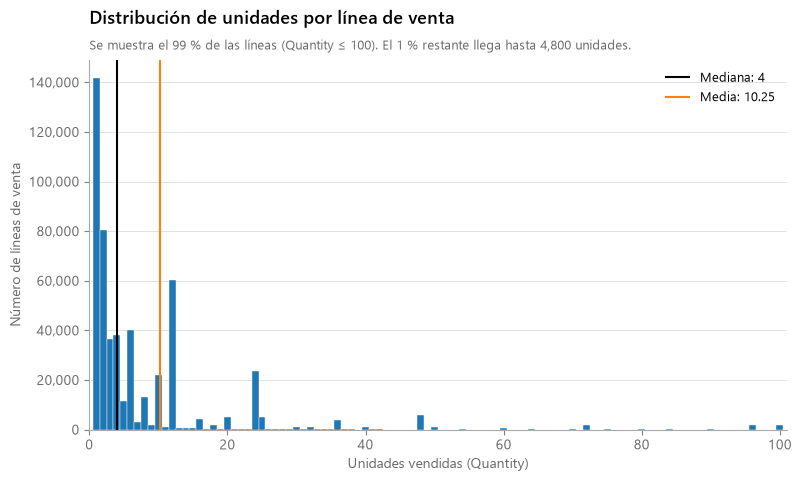

Guardada: outputs/figures/fig01_histograma_quantity.png


In [15]:
# Captura 15: Figura 1. Histograma de frecuencias de Quantity
p99 = df["Quantity"].quantile(0.99)
q = df.loc[df["Quantity"] <= p99, "Quantity"]
media, mediana = df["Quantity"].mean(), df["Quantity"].median()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(q, bins=np.arange(0.5, p99 + 1.5, 1), color=AZUL, edgecolor="white", linewidth=0.3)
ax.axvline(mediana, color=NEGRO, linewidth=1.5)
ax.axvline(media, color=NARANJA, linewidth=1.5)
leyenda_media_mediana(ax, media, mediana, lambda v: f"{v:,.0f}" if v == int(v) else f"{v:,.2f}")
ax.set_title("Distribución de unidades por línea de venta", pad=26)
subtitulo(ax, f"Se muestra el 99 % de las líneas (Quantity ≤ {p99:,.0f}). El 1 % restante llega hasta {df['Quantity'].max():,} unidades.")
ax.set_xlabel("Unidades vendidas (Quantity)")
ax.set_ylabel("Número de líneas de venta")
ax.yaxis.set_major_formatter(miles)
ax.set_xlim(0, p99 + 1)
ax.grid(axis="x", visible=False)
guardar(fig, "fig01_histograma_quantity.png")

**Figura 1.** La barra más alta corresponde a 1 unidad y la frecuencia cae rápidamente. Se observan picos en 6, 12 y 24 unidades, que coinciden con presentaciones por paquete o por docena: el 19.6 % de las líneas son múltiplos de 12. La media (10.25) queda a la derecha de la mediana (4) por el efecto de los pedidos grandes.

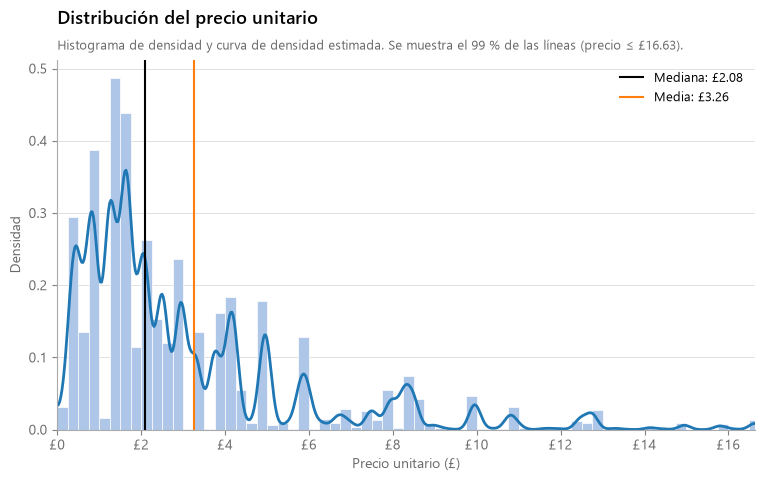

Guardada: outputs/figures/fig02_densidad_price.png


In [16]:
# Captura 16: Figura 2. Histograma y curva de densidad de Price
p99 = df["Price"].quantile(0.99)
pr = df.loc[df["Price"] <= p99, "Price"]
media, mediana = df["Price"].mean(), df["Price"].median()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(pr, bins=np.arange(0, p99 + 0.25, 0.25), density=True, color=AZUL_CLARO, edgecolor="white", linewidth=0.5)
# Curva de densidad con reflexión en £0, porque no existen precios negativos
kde = stats.gaussian_kde(pr.sample(50_000, random_state=2), bw_method=0.05)
xs = np.linspace(0, p99, 600)
ax.plot(xs, kde(xs) + kde(-xs), color=AZUL, linewidth=2)
ax.axvline(mediana, color=NEGRO, linewidth=1.5)
ax.axvline(media, color=NARANJA, linewidth=1.5)
leyenda_media_mediana(ax, media, mediana, lambda v: f"£{v:,.2f}")
ax.set_title("Distribución del precio unitario", pad=26)
subtitulo(ax, f"Histograma de densidad y curva de densidad estimada. Se muestra el 99 % de las líneas (precio ≤ £{p99:,.2f}).")
ax.set_xlabel("Precio unitario (£)")
ax.set_ylabel("Densidad")
ax.set_xlim(0, p99)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.grid(axis="x", visible=False)
guardar(fig, "fig02_densidad_price.png")

**Figura 2.** La mayoría de los precios está por debajo de £5 (84.2 % de las líneas) y la densidad es más alta entre £1 y £2. La curva tiene varios picos porque la tienda maneja precios fijos que se repiten en muchos productos, como £1.25. Como la curva suaviza esos precios fijos, su altura no coincide exactamente con la de las barras. La curva se estimó con una muestra aleatoria de 50,000 líneas.

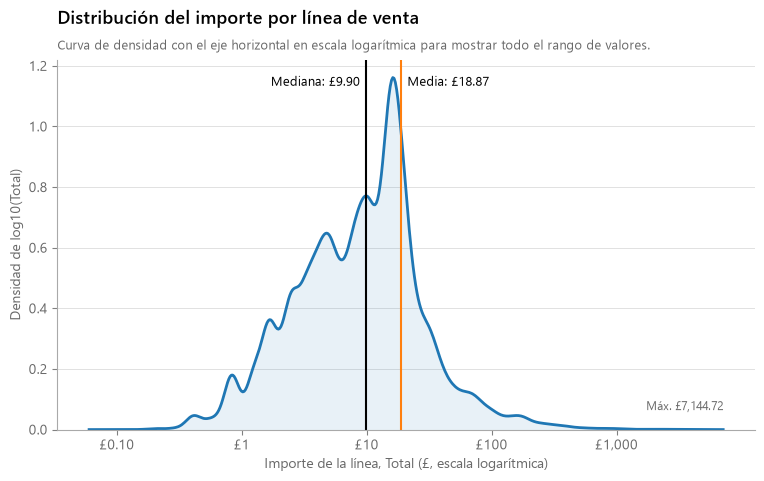

Guardada: outputs/figures/fig03_densidad_total.png


In [17]:
# Captura 17: Figura 3. Curva de densidad de Total en escala logarítmica
log_total = np.log10(df["Total"])
kde = stats.gaussian_kde(log_total.sample(50_000, random_state=2))
xs = np.linspace(log_total.min(), log_total.max(), 500)
media, mediana = df["Total"].mean(), df["Total"].median()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.fill_between(xs, kde(xs), color=AZUL, alpha=0.10, linewidth=0)
ax.plot(xs, kde(xs), color=AZUL, linewidth=2)
ax.axvline(np.log10(mediana), color=NEGRO, linewidth=1.5)
ax.axvline(np.log10(media), color=NARANJA, linewidth=1.5)
ymax = ax.get_ylim()[1]
ax.text(np.log10(mediana) - 0.05, ymax * 0.93, f"Mediana: £{mediana:,.2f}", color=NEGRO, fontsize=9, ha="right")
ax.text(np.log10(media) + 0.05, ymax * 0.93, f"Media: £{media:,.2f}", color=NEGRO, fontsize=9)
ax.set_title("Distribución del importe por línea de venta", pad=26)
subtitulo(ax, "Curva de densidad con el eje horizontal en escala logarítmica para mostrar todo el rango de valores.")
ax.set_xlabel("Importe de la línea, Total (£, escala logarítmica)")
ax.set_ylabel("Densidad de log10(Total)")
ticks = [0.1, 1, 10, 100, 1000]
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([f"£{t:,.2f}" if t < 1 else f"£{t:,.0f}" for t in ticks])
ax.set_ylim(bottom=0)
ax.annotate(f"Máx. £{df['Total'].max():,.2f}", (log_total.max(), 0), xytext=(0, 14), textcoords="offset points",
            ha="right", fontsize=8.5, color=GRIS_OSCURO)
ax.grid(axis="x", visible=False)
guardar(fig, "fig03_densidad_total.png")

**Figura 3.** Con el eje horizontal en escala logarítmica, el importe se ve mucho más simétrico que en escala normal, aunque con varios picos, y su punto más alto está entre £10 y £20. La curva se estimó con una muestra aleatoria de 50,000 líneas. La cola derecha llega hasta £7,144.72.

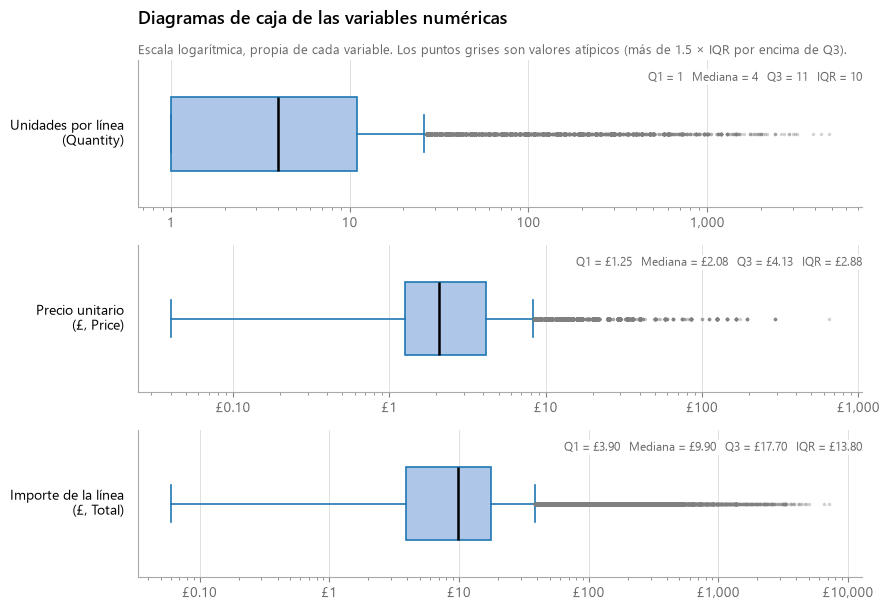

Guardada: outputs/figures/fig04_boxplots.png


In [18]:
# Captura 18: Figura 4. Diagramas de caja y bigotes
etiquetas = {"Quantity": "Unidades por línea\n(Quantity)", "Price": "Precio unitario\n(£, Price)", "Total": "Importe de la línea\n(£, Total)"}

fig, axes = plt.subplots(3, 1, figsize=(9, 6.2))
for ax, v in zip(axes, VARIABLES):
    s = df[v]
    ax.boxplot(s, **HORIZONTAL, widths=0.5, whis=1.5, patch_artist=True,
               boxprops=dict(facecolor=AZUL_CLARO, edgecolor=AZUL, linewidth=1.2),
               medianprops=dict(color=NEGRO, linewidth=1.8),
               whiskerprops=dict(color=AZUL, linewidth=1.2), capprops=dict(color=AZUL, linewidth=1.2),
               flierprops=dict(marker="o", markersize=2.5, markerfacecolor=GRIS, markeredgewidth=0, alpha=0.35))
    ax.set_xscale("log")
    moneda = "" if v == "Quantity" else "£"
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _, m=moneda: f"{m}{x:,.2f}" if x < 1 else f"{m}{x:,.0f}"))
    ax.set_yticks([])
    ax.set_ylabel(etiquetas[v], rotation=0, ha="right", va="center", color=NEGRO, labelpad=10)
    q1, med, q3 = s.quantile([0.25, 0.5, 0.75])
    f = (lambda x: f"{x:,.0f}") if v == "Quantity" else (lambda x: f"£{x:,.2f}")
    ax.text(1.0, 0.92, f"Q1 = {f(q1)}   Mediana = {f(med)}   Q3 = {f(q3)}   IQR = {f(q3 - q1)}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=GRIS_OSCURO,
            bbox=dict(facecolor="white", edgecolor="none", pad=1))
    ax.grid(axis="y", visible=False)
axes[0].set_title("Diagramas de caja de las variables numéricas", pad=26)
subtitulo(axes[0], "Escala logarítmica, propia de cada variable. Los puntos grises son valores atípicos (más de 1.5 × IQR por encima de Q3).")
fig.tight_layout()
guardar(fig, "fig04_boxplots.png")

**Figura 4.** En las tres variables la caja está cargada a la izquierda y hay muchos valores atípicos a la derecha, lo que coincide con la asimetría positiva. Los bigotes superiores llegan hasta el último valor que no rebasa el límite de 1.5 × IQR: 26 unidades, £8.33 y £38.40 (los límites son 26, £8.45 y £38.40).

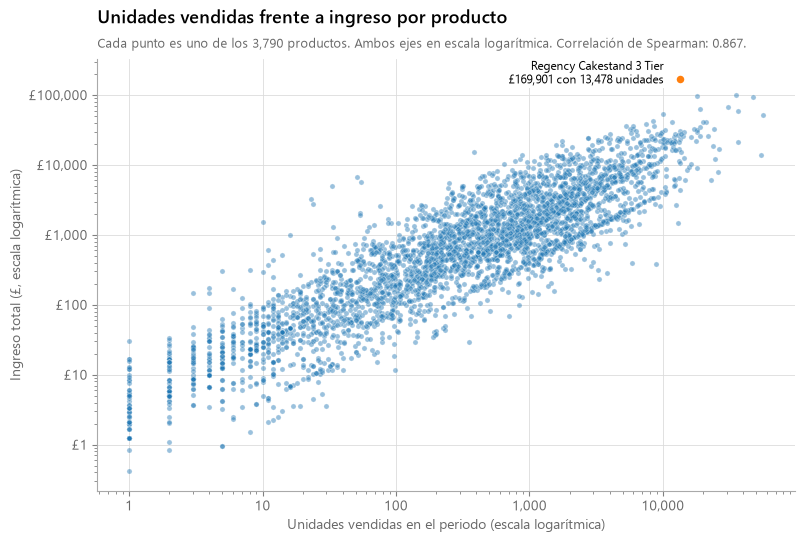

Guardada: outputs/figures/fig05_dispersion_unidades_ingreso.png


In [19]:
# Captura 19: Figura 5. Dispersión entre unidades vendidas e ingreso por producto
rho = productos[["Unidades", "Ingreso"]].corr(method="spearman").iloc[0, 1]
top = productos.loc[productos["Ingreso"].idxmax()]

fig, ax = plt.subplots(figsize=(9, 5.6))
ax.scatter(productos["Unidades"], productos["Ingreso"], s=14, color=AZUL, alpha=0.45, edgecolors="white", linewidths=0.4)
ax.scatter(top["Unidades"], top["Ingreso"], s=48, color=NARANJA, edgecolors="white", linewidths=1.5, zorder=3)
ax.annotate(f"{capwords(top['Description'].lower())}\n£{top['Ingreso']:,.0f} con {top['Unidades']:,} unidades",
            (top["Unidades"], top["Ingreso"]), xytext=(-12, 4), textcoords="offset points",
            bbox=dict(facecolor="white", edgecolor="none", pad=1),
            ha="right", va="center", fontsize=8.5, color=NEGRO)
ax.set_xscale("log"); ax.set_yscale("log")
ax.xaxis.set_major_formatter(miles); ax.yaxis.set_major_formatter(libras)
ax.set_title("Unidades vendidas frente a ingreso por producto", pad=26)
subtitulo(ax, f"Cada punto es uno de los {len(productos):,} productos. Ambos ejes en escala logarítmica. Correlación de Spearman: {rho:.3f}.")
ax.set_xlabel("Unidades vendidas en el periodo (escala logarítmica)")
ax.set_ylabel("Ingreso total (£, escala logarítmica)")
guardar(fig, "fig05_dispersion_unidades_ingreso.png")

**Figura 5.** La nube de puntos sigue una tendencia ascendente clara (Spearman 0.867): los productos que venden más unidades generan más ingreso. La dispersión vertical para una misma cantidad de unidades se debe a las diferencias de precio. El producto con mayor ingreso es Regency Cakestand 3 Tier, con £169,901 y 13,478 unidades.

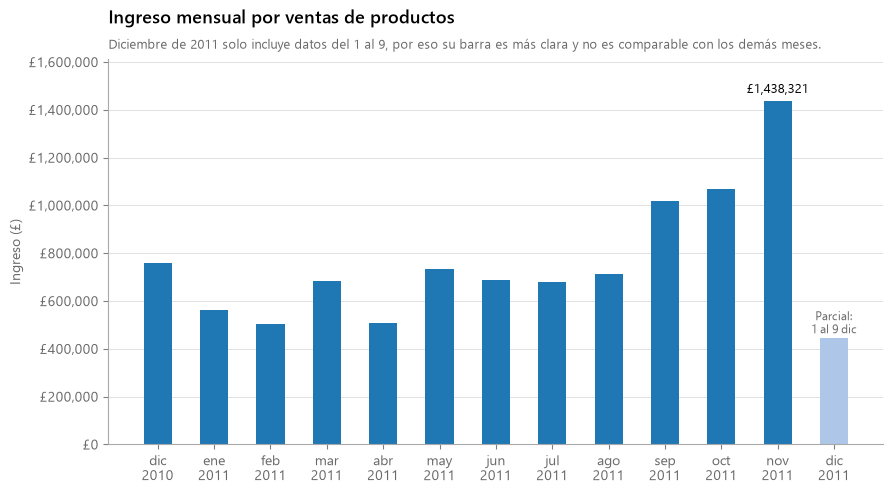

Guardada: outputs/figures/fig06_ingreso_mensual.png


In [20]:
# Captura 20: Figura 6. Ingreso mensual
mensual = df.groupby(df["InvoiceDate"].dt.to_period("M")).agg(
    Ingreso=("Total", "sum"), Facturas=("Invoice", "nunique"), Unidades=("Quantity", "sum"))
mensual.round(2).to_csv(TABLES / "monthly_sales.csv", lineterminator="\n")

MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
etiquetas_mes = [f"{MESES[p.month - 1]}\n{p.year}" for p in mensual.index]
ultimo_dia = df["InvoiceDate"].max().day
colores = [AZUL] * (len(mensual) - 1) + [AZUL_CLARO]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(mensual))
ax.bar(x, mensual["Ingreso"], width=0.5, color=colores)
pico = mensual["Ingreso"].idxmax()
i_pico = list(mensual.index).index(pico)
ax.text(i_pico, mensual.loc[pico, "Ingreso"] * 1.015, f"£{mensual.loc[pico, 'Ingreso']:,.0f}", ha="center", va="bottom", fontsize=9, color=NEGRO)
ax.text(x[-1], mensual["Ingreso"].iloc[-1] * 1.015, f"Parcial:\n1 al {ultimo_dia} dic", ha="center", va="bottom", fontsize=8.5, color=GRIS_OSCURO)
ax.set_xticks(x, etiquetas_mes)
ax.yaxis.set_major_formatter(libras)
ax.set_title("Ingreso mensual por ventas de productos", pad=26)
subtitulo(ax, "Diciembre de 2011 solo incluye datos del 1 al 9, por eso su barra es más clara y no es comparable con los demás meses.")
ax.set_ylabel("Ingreso (£)")
ax.grid(axis="x", visible=False)
ax.set_ylim(0, mensual["Ingreso"].max() * 1.12)
guardar(fig, "fig06_ingreso_mensual.png")

**Figura 6.** De diciembre de 2010 a agosto de 2011 el ingreso mensual se mantuvo entre £504,587 y £760,089. A partir de septiembre aumentó y en noviembre de 2011 alcanzó £1,438,321, 2.27 veces el promedio de enero a agosto (se excluye diciembre de 2010 porque también es temporada navideña). El aumento coincide con la temporada previa a Navidad, lo que es congruente con un catálogo de artículos de regalo.

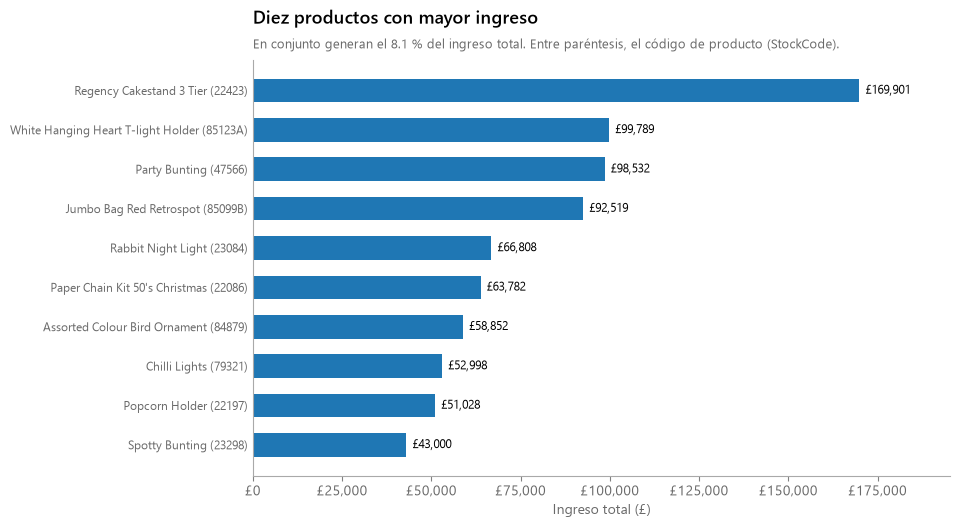

Guardada: outputs/figures/fig07_top10_productos.png


In [21]:
# Captura 21: Figura 7. Diez productos con mayor ingreso
top10 = productos.nlargest(10, "Ingreso").iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.4))
y = np.arange(len(top10))
ax.barh(y, top10["Ingreso"], height=0.6, color=AZUL)
for yi, (ing, uni) in enumerate(zip(top10["Ingreso"], top10["Unidades"])):
    ax.text(ing + top10["Ingreso"].max() * 0.01, yi, f"£{ing:,.0f}", va="center", fontsize=8.5, color=NEGRO)
ax.set_yticks(y, [f"{capwords(d.lower())} ({c})" for c, d in zip(top10.index, top10["Description"])], fontsize=8.5)
ax.xaxis.set_major_formatter(libras)
ax.set_xlim(0, top10["Ingreso"].max() * 1.15)
participacion = top10["Ingreso"].sum() / productos["Ingreso"].sum() * 100
ax.set_title("Diez productos con mayor ingreso", pad=26)
subtitulo(ax, f"En conjunto generan el {participacion:.1f} % del ingreso total. Entre paréntesis, el código de producto (StockCode).")
ax.set_xlabel("Ingreso total (£)")
ax.grid(False)
ax.tick_params(axis="y", length=0)
guardar(fig, "fig07_top10_productos.png")

**Figura 7.** Los diez productos con mayor ingreso suman el 8.1 % del total. El primero, Regency Cakestand 3 Tier, generó £169,901, un 70 % más que el segundo, White Hanging Heart T-light Holder (£99,789).

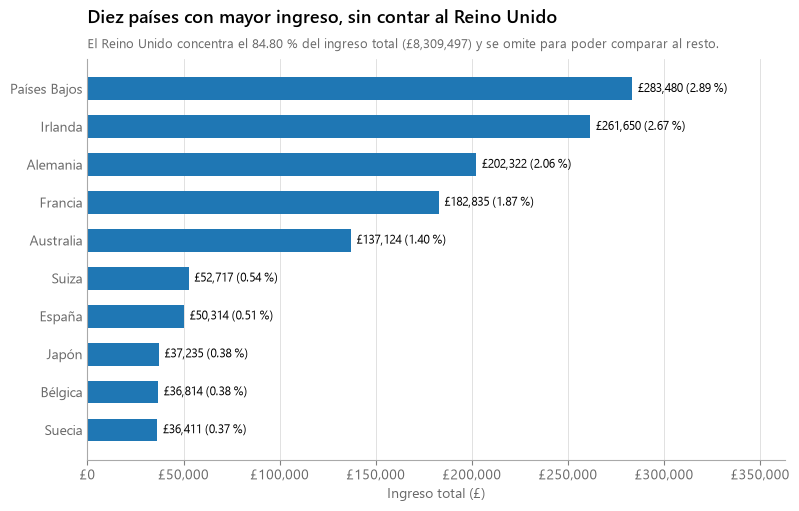

Guardada: outputs/figures/fig08_ingreso_por_pais.png


In [22]:
# Captura 22: Figura 8. Ingreso por país (sin Reino Unido)
PAISES = {"Netherlands": "Países Bajos", "EIRE": "Irlanda", "Germany": "Alemania", "France": "Francia",
          "Australia": "Australia", "Switzerland": "Suiza", "Spain": "España", "Belgium": "Bélgica",
          "Sweden": "Suecia", "Japan": "Japón", "Norway": "Noruega", "Portugal": "Portugal",
          "Finland": "Finlandia", "Channel Islands": "Islas del Canal", "Denmark": "Dinamarca",
          "Italy": "Italia", "Cyprus": "Chipre", "Singapore": "Singapur", "Austria": "Austria"}
paises = df[~df["Country"].isin(["Unspecified", "European Community"])].groupby("Country")["Total"].sum()
paises = paises.sort_values(ascending=False)
# El porcentaje se calcula sobre el ingreso total, incluidas las ventas sin país identificado
pais_pct = paises / df["Total"].sum() * 100
pais_pct.rename("Porcentaje").to_frame().join(paises.rename("Ingreso")).round(4).to_csv(TABLES / "revenue_by_country.csv", lineterminator="\n")

top_paises = paises.drop("United Kingdom").head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.2))
y = np.arange(len(top_paises))
ax.barh(y, top_paises, height=0.6, color=AZUL)
for yi, (pais, ing) in enumerate(top_paises.items()):
    ax.text(ing + top_paises.max() * 0.01, yi, f"£{ing:,.0f} ({pais_pct[pais]:.2f} %)", va="center", fontsize=8.5, color=NEGRO)
ax.set_yticks(y, [PAISES.get(p, p) for p in top_paises.index])
ax.xaxis.set_major_formatter(libras)
ax.set_xlim(0, top_paises.max() * 1.28)
ax.set_title("Diez países con mayor ingreso, sin contar al Reino Unido", pad=26)
subtitulo(ax, f"El Reino Unido concentra el {pais_pct['United Kingdom']:.2f} % del ingreso total "
              f"(£{paises['United Kingdom']:,.0f}) y se omite para poder comparar al resto.")
ax.set_xlabel("Ingreso total (£)")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
guardar(fig, "fig08_ingreso_por_pais.png")

**Figura 8.** El Reino Unido concentra el 84.80 % del ingreso total, por lo que se omite para poder comparar a los demás países. Le siguen Países Bajos (2.89 %), Irlanda (2.67 %), Alemania (2.06 %) y Francia (1.87 %).

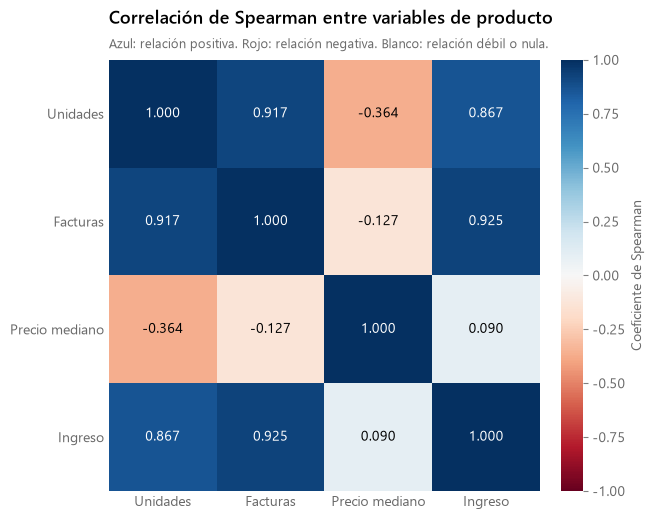

Guardada: outputs/figures/fig09_correlacion_productos.png


In [23]:
# Captura 23: Figura 9. Mapa de calor de la correlación de Spearman por producto
nombres = {"Unidades": "Unidades", "Facturas": "Facturas", "PrecioMediano": "Precio mediano", "Ingreso": "Ingreso"}
m = corr_productos.rename(index=nombres, columns=nombres)
cmap = "RdBu"

fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(m, cmap=cmap, vmin=-1, vmax=1)
for i in range(len(m)):
    for j in range(len(m)):
        val = m.iloc[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=10,
                color="white" if abs(val) > 0.6 else NEGRO)
ax.set_xticks(range(len(m)), m.columns)
ax.set_yticks(range(len(m)), m.index)
ax.tick_params(length=0)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.outline.set_visible(False)
cb.set_label("Coeficiente de Spearman", color=GRIS_OSCURO)
cb.ax.tick_params(color=GRIS, labelcolor=GRIS_OSCURO)
ax.set_title("Correlación de Spearman entre variables de producto", pad=26)
subtitulo(ax, "Azul: relación positiva. Rojo: relación negativa. Blanco: relación débil o nula.")
guardar(fig, "fig09_correlacion_productos.png")

**Figura 9.** La correlación más alta es entre facturas e ingreso (0.925): el ingreso de un producto se relaciona sobre todo con cuántas veces se vende. El precio mediano casi no se relaciona con el ingreso (0.090) y tiene una correlación negativa con las unidades vendidas (-0.364).

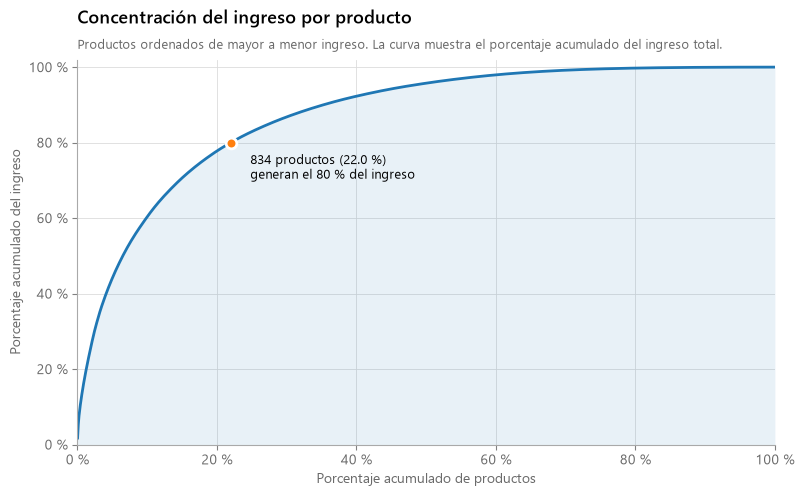

Guardada: outputs/figures/fig10_pareto_ingreso.png


In [24]:
# Captura 24: Figura 10. Concentración del ingreso por producto (curva de Pareto)
orden = productos["Ingreso"].sort_values(ascending=False)
x_pct = np.arange(1, len(orden) + 1) / len(orden) * 100
y_pct = orden.cumsum().to_numpy() / orden.sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(x_pct, y_pct, color=AZUL, alpha=0.10, linewidth=0)
ax.plot(x_pct, y_pct, color=AZUL, linewidth=2)
x80 = n_80 / len(orden) * 100
ax.scatter([x80], [80], s=60, color=NARANJA, edgecolors="white", linewidths=2, zorder=3)
ax.annotate(f"{n_80:,} productos ({x80:.1f} %)\ngeneran el 80 % del ingreso", (x80, 80),
            xytext=(14, -26), textcoords="offset points", fontsize=9, color=NEGRO)
ax.set_xlim(0, 100); ax.set_ylim(0, 102)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} %"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} %"))
ax.set_title("Concentración del ingreso por producto", pad=26)
subtitulo(ax, "Productos ordenados de mayor a menor ingreso. La curva muestra el porcentaje acumulado del ingreso total.")
ax.set_xlabel("Porcentaje acumulado de productos")
ax.set_ylabel("Porcentaje acumulado del ingreso")
guardar(fig, "fig10_pareto_ingreso.png")

**Figura 10.** La curva sube muy rápido al inicio: 834 productos (22.0 %) generan el 80 % del ingreso, mientras que la mitad de los productos con menor ingreso aporta solo el 4.3 %. Es un comportamiento parecido a la regla de Pareto.

## 6. Conclusiones

1. **Las ventas son pequeñas y asimétricas.** Las tres variables tienen asimetría positiva fuerte. La venta típica es de 4 unidades, £2.08 por unidad y £9.90 por línea (medianas). Por eso la mediana y el rango intercuartílico describen mejor estos datos que la media y la desviación estándar.
2. **Los valores atípicos son parte del negocio.** Entre el 5.14 % y el 7.80 % de las líneas son atípicas. Son pedidos de mayoreo y productos de precio alto, y explican que la desviación estándar de Quantity (36.95) sea mucho mayor que su IQR (10).
3. **Precio y cantidad tienen una relación inversa.** La correlación de Spearman entre ambos es de -0.406: los productos baratos se compran en mayores cantidades. El importe de una línea se relaciona más con la cantidad (0.684) que con el precio (0.329), en parte porque el importe se calcula como cantidad por precio.
4. **El ingreso se relaciona con la frecuencia de venta, no con el precio.** A nivel producto, la correlación entre facturas e ingreso es de 0.925 y entre precio e ingreso de solo 0.090. Como 834 productos (22.0 %) generan el 80 % del ingreso, conviene priorizar su disponibilidad en el inventario.
5. **Las ventas aumentan antes de Navidad.** Noviembre de 2011 fue 2.27 veces el promedio mensual de enero a agosto, y diciembre de 2010 fue el mes más alto antes de septiembre. Con un solo año de datos no se puede confirmar que el patrón se repita, pero es congruente con un catálogo de regalos y sugiere aumentar las existencias de los productos principales desde septiembre.
6. **El mercado principal es el Reino Unido.** Aporta el 84.80 % del ingreso. Los mercados internacionales más importantes son Países Bajos, Irlanda, Alemania y Francia, que juntos suman 9.49 %.
7. **La limpieza fue necesaria.** Sin eliminar las compras canceladas, la cantidad máxima habría sido de 80,995 unidades en lugar de 4,800, lo que habría inflado la media y la varianza de Quantity y de Total.

## 7. Validación final de resultados

La siguiente celda comprueba que las cifras principales de las interpretaciones y conclusiones son las que produce el notebook. Si cualquier valor cambia (por ejemplo, al ejecutarlo en otra computadora o en Colab con otras versiones de las librerías), la celda se detiene con un error.

In [25]:
# Captura 25: Validación final de resultados
esperado = {
    "Filas del conjunto limpio": (len(df), 519_231),
    "Productos distintos": (df["StockCode"].nunique(), 3_790),
    "Facturas": (df["Invoice"].nunique(), 19_627),
    "Ingreso total (£)": (round(df["Total"].sum(), 2), 9_798_951.95),
    "Media de Quantity": (round(df["Quantity"].mean(), 2), 10.25),
    "Mediana de Quantity": (df["Quantity"].median(), 4),
    "Moda de Price (£)": (df["Price"].mode().iloc[0], 1.25),
    "Desviación estándar de Quantity": (round(df["Quantity"].std(), 2), 36.95),
    "IQR de Total (£)": (round(df["Total"].quantile(0.75) - df["Total"].quantile(0.25), 2), 13.80),
    "Spearman Quantity y Price": (round(spearman.loc["Quantity", "Price"], 3), -0.406),
    "Spearman facturas e ingreso por producto": (round(corr_productos.loc["Facturas", "Ingreso"], 3), 0.925),
    "Productos que generan el 80 % del ingreso": (n_80, 834),
    "Ingreso de noviembre de 2011 (£)": (round(mensual.loc[pd.Period("2011-11", "M"), "Ingreso"], 0), 1_438_321),
    "Participación de Reino Unido (%)": (round(pais_pct["United Kingdom"], 2), 84.80),
    "Gráficas generadas": (len(list(FIGURES.glob("fig*.png"))), 10),
}
validacion = pd.DataFrame([(k, float(v[0]), float(v[1]), bool(np.isclose(v[0], v[1]))) for k, v in esperado.items()],
                          columns=["Concepto", "Obtenido", "Esperado", "Coincide"])
formato = lambda v: f"{v:,.0f}" if float(v).is_integer() else (f"{v:.3f}" if abs(v) < 1 else f"{v:,.2f}")
display(validacion.style.format({"Obtenido": formato, "Esperado": formato}).hide(axis="index"))
assert validacion["Coincide"].all(), "Hay resultados que no coinciden con los esperados"
print("Todas las cifras del análisis coinciden con las esperadas.")

Concepto,Obtenido,Esperado,Coincide
Filas del conjunto limpio,"519,231","519,231",True
Productos distintos,"3,790","3,790",True
Facturas,"19,627","19,627",True
Ingreso total (£),"9,798,951.95","9,798,951.95",True
Media de Quantity,10.25,10.25,True
Mediana de Quantity,4,4,True
Moda de Price (£),1.25,1.25,True
Desviación estándar de Quantity,36.95,36.95,True
IQR de Total (£),13.80,13.80,True
Spearman Quantity y Price,-0.406,-0.406,True


Todas las cifras del análisis coinciden con las esperadas.
